In [1]:
import numpy as np
import string
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import astropy.units as u
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord
from matplotlib.patches import Ellipse
from astropy.stats import mad_std
import matplotlib as mpl
from photutils.profiles import RadialProfile
from matplotlib.patches import Circle


In [2]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Set Definitions

In [3]:
def plot_contours(data_array, color, sigma_m0, sigma_min, sigma_max, sigma_step):
    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma_m0 * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=[
            ra_offsets.min(), ra_offsets.max(),
            dec_offsets.min(), dec_offsets.max()
        ],
    )


def beam(beam_minor, beam_major, beam_pa, beam_position):
    # Set beam location
    beam_x = ra_offsets.min() + beam_position + 1
    beam_y = dec_offsets.min() + beam_position

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )


# Find Beam Values

In [4]:
# Load the FITS file
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits'
fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_cont_robust0.5.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_Continuum_natural_thres0.4mJy.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/CARMA/CARMA_NRO_Orion_N2Dp_HOPS-164_cut.fits'

hdu = fits.open(fits_file)[0]  # Open the primary HDU
wcs = WCS(hdu.header)          # Extract WCS projection

header = hdu.header

# Extract beam parameters and convert degrees to arcminutes
bmaj = (header.get('BMAJ', 0) * u.deg).to(u.arcmin)
bmin = (header.get('BMIN', 0) * u.deg).to(u.arcmin)
bpa  = header.get('BPA', 0)         # position angle in degrees

print(f"Beam major axis: {bmaj:.3f}'")
print(f"Beam minor axis: {bmin:.3f}'")
print(f"Beam position angle: {bpa:.2f}°")

Beam major axis: 0.021 arcmin'
Beam minor axis: 0.016 arcmin'
Beam position angle: 84.20°


# C18O

# Read Cube and Find RMS Value

In [5]:
cube_C18O=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked.fits')
cube_C18O = cube_C18O.to(u.K).with_spectral_unit(u.km/u.s)

In [6]:
sigma_m5_C18O = 0.13

# Set Radial Parameters

In [7]:


# Actual Coordinates checked in CARMA
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')
x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_C18O.wcs.celestial)
print(x_marker, y_marker)

# Pick center
xycen = (x_marker, y_marker)

# Choose to where you want the plot (pixels per step)
edge_radii = np.arange(0, 148, 1)
pixel_scale = 0.17  # arcsec per pixel

228.60662394208083 220.4771254368455


# C18O Channel Maps

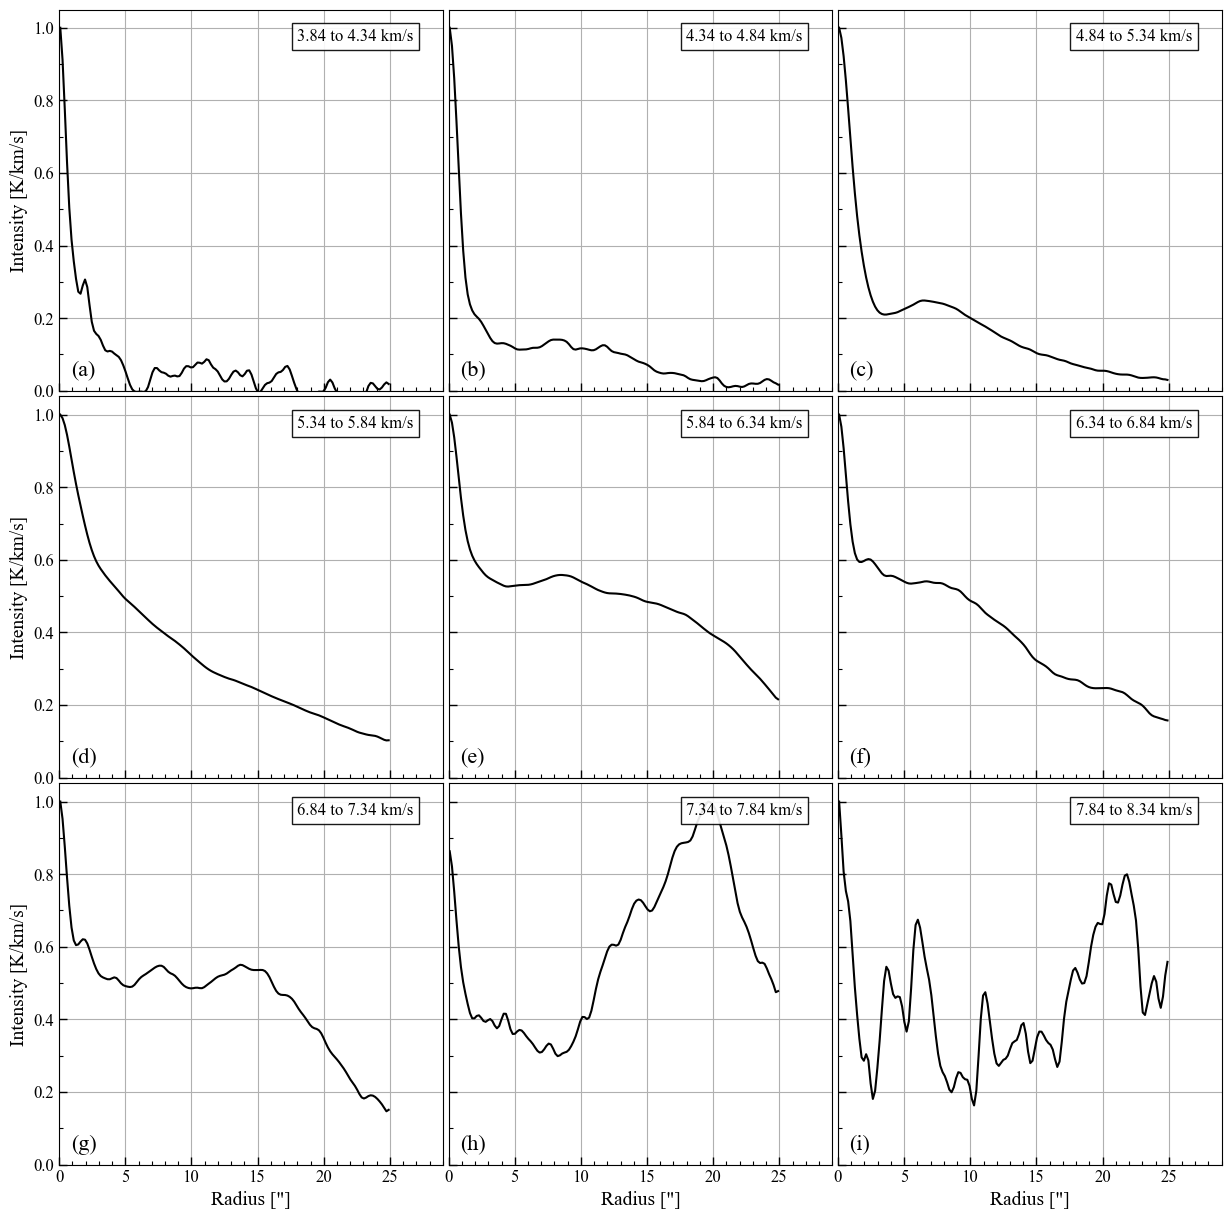

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(3.84, 8.35, 0.5)

for idx, v in enumerate(vel_bins[:-1]):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_C18O = cube_C18O.spectral_slab(v_start, v_end)
    moment0_C18O = slab_C18O.moment0().value

    # Make the radial profile
    rp_C18O = RadialProfile(moment0_C18O, xycen, edge_radii)
    radius_arcsec_C18O = rp_C18O.radius * pixel_scale
    max_C18O = np.nanmax(rp_C18O.profile)

    # Plot the radial map
    ax.plot(radius_arcsec_C18O, rp_C18O.profile / max_C18O, '-', color='black', markersize=3)
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.03, 0.08, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    ax.set_xlim(0, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(0, 26, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(0, 30, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Intensity [K/km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_C18O_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_C18O_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# H2CO

# Read Cube and Find RMS Value

In [9]:
cube_H2CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_H2CO = cube_H2CO.to(u.K).with_spectral_unit(u.km/u.s)

In [10]:
sigma_m5_H2CO = 0.11

# Set Offset

In [11]:

# Actual Coordinates checked in CARMA
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')
x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_H2CO.wcs.celestial)
print(x_marker, y_marker)

# Pick center
xycen = (x_marker, y_marker)

# Choose to where you want the plot (pixels per step)
edge_radii = np.arange(0, 148, 1)
pixel_scale = 0.17  # arcsec per pixel

228.60662394208083 220.4771254368455


# H2CO Channel Maps

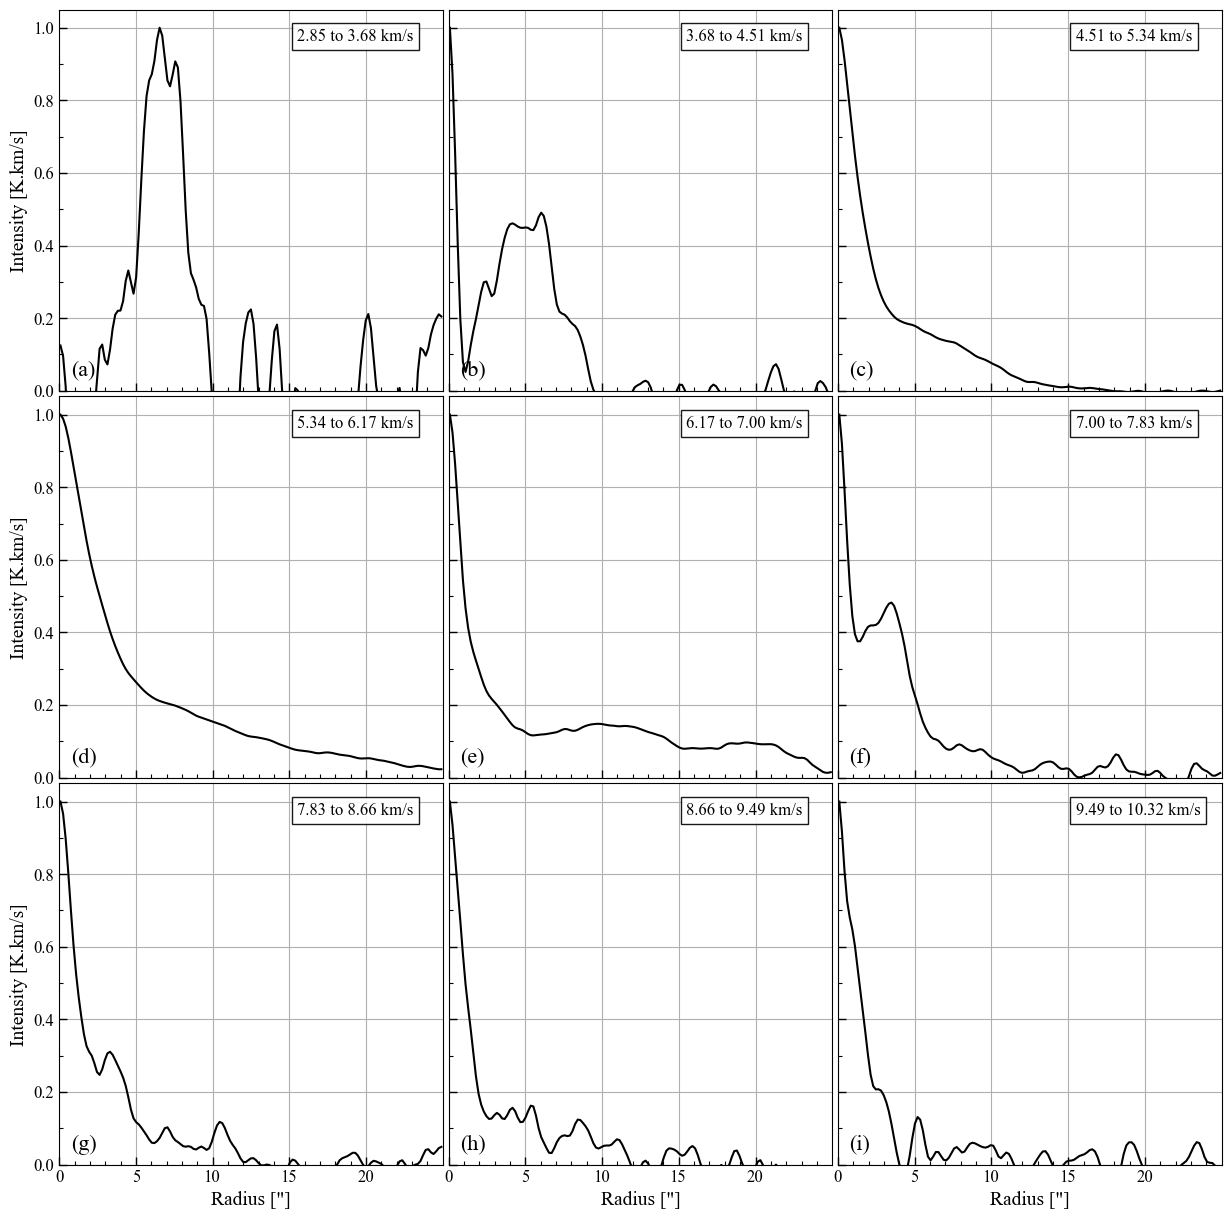

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(2.85, 10.41, 0.83)

for idx, v in enumerate(vel_bins[:-1]): 
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_H2CO = cube_H2CO.spectral_slab(v_start, v_end)
    moment0_H2CO = slab_H2CO.moment0().value

    # Make the radial profile
    rp_H2CO = RadialProfile(moment0_H2CO, xycen, edge_radii)
    radius_arcsec_H2CO = rp_H2CO.radius * pixel_scale
    max_H2CO = np.nanmax(rp_H2CO.profile)

    # Plot the radial map
    ax.plot(radius_arcsec_H2CO, rp_H2CO.profile / max_H2CO, '-', color='black', markersize=3)
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.03, 0.08, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    ax.set_xlim(0, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(0, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(0, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_H2CO_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_H2CO_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# Read Cube and Find RMS Value

In [13]:
# cube_N2Dp =SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits')
# cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

cube_N2Dp = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits')
cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

In [14]:

# Actual Coordinates checked in CARMA
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')
x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_N2Dp.wcs.celestial)
print(x_marker, y_marker)

# Pick center
xycen_N2Dp = (x_marker, y_marker)

# Choose to where you want the plot (pixels per step)

# # large_combine
# edge_radii_N2Dp = np.arange(0, 148, 1)
# pixel_scale_N2Dp = 0.34 

# large_sm_reb
edge_radii_N2Dp = np.arange(0, 74, 1)
pixel_scale_N2Dp = 0.34  


114.05331197104042 109.98856271842276


# N2D+ Channel Maps

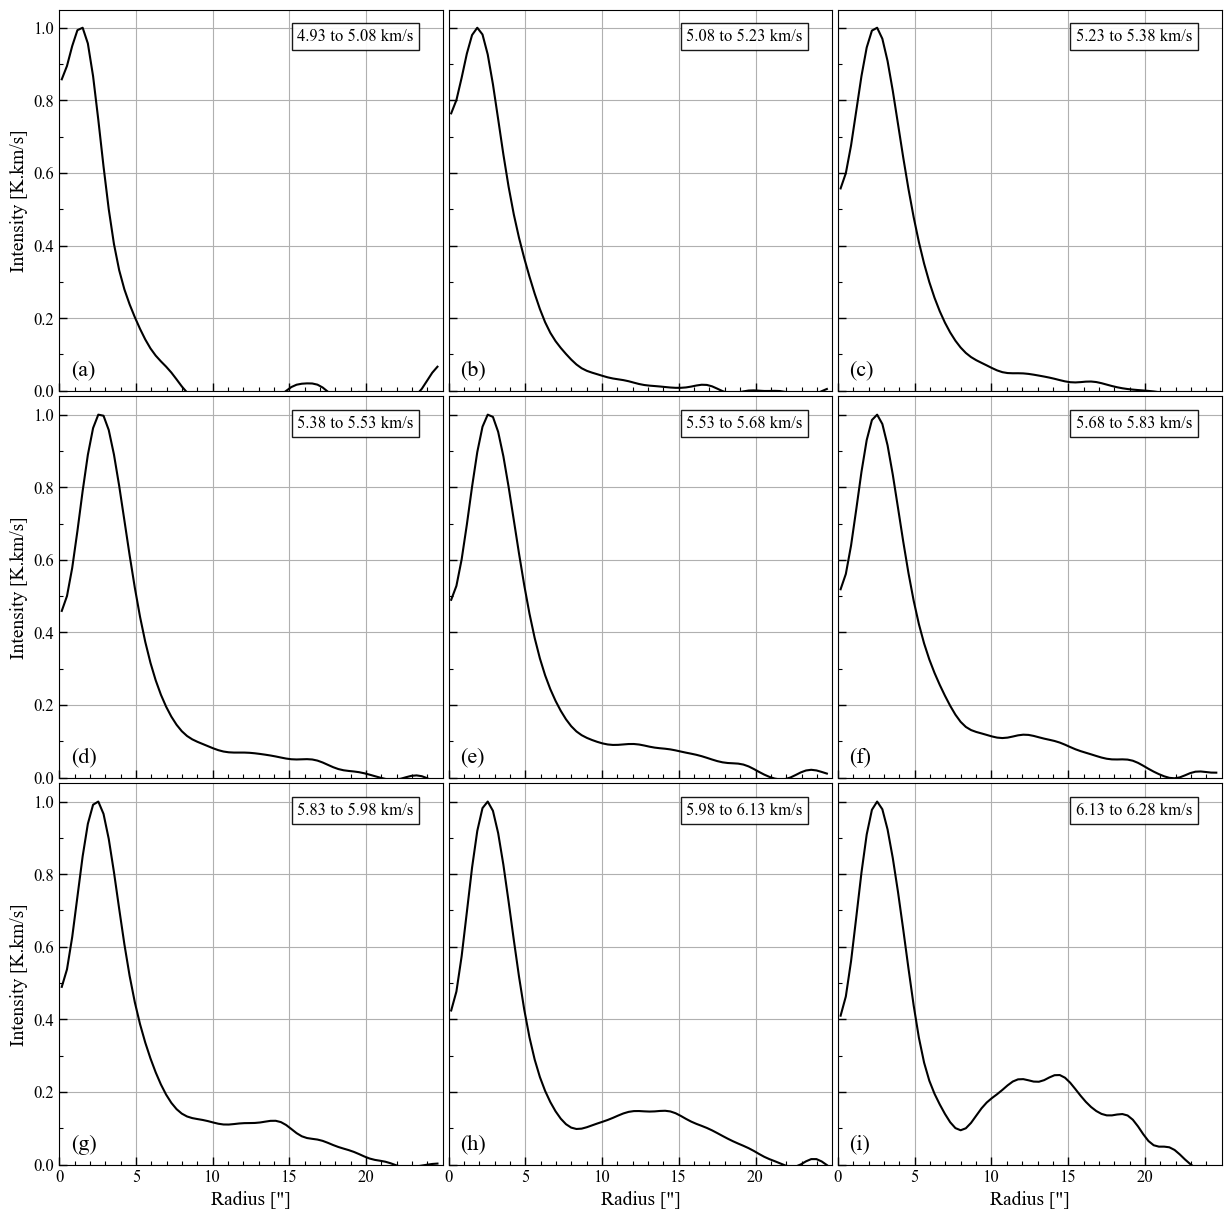

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(4.93, 6.36, 0.15)

for idx, v in enumerate(vel_bins[:-1]):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_N2Dp = cube_N2Dp.spectral_slab(v_start, v_end)
    moment0_N2Dp = slab_N2Dp.moment0().value

    # Make the radial profile
    rp_N2Dp = RadialProfile(moment0_N2Dp, xycen_N2Dp, edge_radii_N2Dp)
    radius_arcsec_N2Dp = rp_N2Dp.radius * pixel_scale_N2Dp
    max_N2Dp = np.nanmax(rp_N2Dp.profile)

    # Plot the radial map
    ax.plot(radius_arcsec_N2Dp, rp_N2Dp.profile / max_N2Dp, '-', color='black', markersize=3)
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.03, 0.08, f"({label})", transform=ax.transAxes, fontsize=16, va='top', ha='left')

    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    ax.set_xlim(0, 25)
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(0, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(0, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_N2Dp_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# Comparison

In [16]:
v_start_C18O = 3.84 * u.km / u.s
v_end_C18O = 8.35 * u.km / u.s

v_start_H2CO = 2.85 * u.km / u.s
v_end_H2CO = 10.41 * u.km / u.s

v_start_N2Dp = 4.93 * u.km / u.s
v_end_N2Dp   = 6.36 * u.km / u.s

# --- Compute moment maps ONCE ---
slab_C18O = cube_C18O.spectral_slab(v_start_C18O, v_end_C18O)
moment0_C18O = slab_C18O.moment0().value

slab_H2CO = cube_H2CO.spectral_slab(v_start_H2CO, v_end_H2CO)
moment0_H2CO = slab_H2CO.moment0().value

slab_N2Dp = cube_N2Dp.spectral_slab(v_start_N2Dp, v_end_N2Dp)
moment0_N2Dp = slab_N2Dp.moment0().value


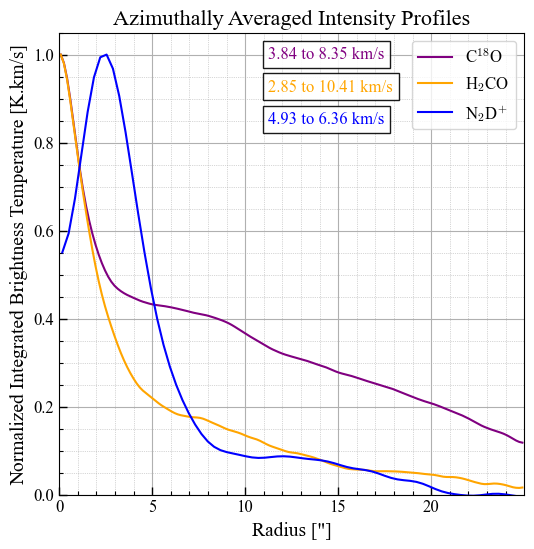

In [23]:
fig, ax = plt.subplots(figsize=(6, 6)) 

# Make the radial profile
rp_C18O = RadialProfile(moment0_C18O, xycen, edge_radii)
radius_arcsec_C18O = rp_C18O.radius * pixel_scale
max_C18O = np.nanmax(rp_C18O.profile)
    
# Make the radial profile
rp_H2CO = RadialProfile(moment0_H2CO, xycen, edge_radii)
radius_arcsec_H2CO = rp_H2CO.radius * pixel_scale
max_H2CO = np.nanmax(rp_H2CO.profile)

# Make the radial profile
rp_N2Dp = RadialProfile(moment0_N2Dp, xycen_N2Dp, edge_radii_N2Dp)
radius_arcsec_N2Dp = rp_N2Dp.radius * pixel_scale_N2Dp
max_N2Dp = np.nanmax(rp_N2Dp.profile)

# Plot the radial map
ax.plot(radius_arcsec_C18O, rp_C18O.profile / max_C18O, '-', color='purple', label=r'C$^{18}$O')
ax.plot(radius_arcsec_H2CO, rp_H2CO.profile / max_H2CO, '-', color='orange', label=r'H$_{2}$CO')
ax.plot(radius_arcsec_N2Dp, rp_N2Dp.profile / max_N2Dp, '-', color='blue', label=r'N$_{2}$D$^{+}$')

# Add velocity label in the top left of the subplot
ax.text(0.45, 0.97,
    f"{v_start_C18O.value:.2f} to {v_end_C18O.value:.2f} km/s",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    color='purple',
    bbox=dict(facecolor='white', alpha=0.9))
    
ax.text(0.45, 0.90,
    f"{v_start_H2CO.value:.2f} to {v_end_H2CO.value:.2f} km/s",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    color='orange',
    bbox=dict(facecolor='white', alpha=0.9))
    
ax.text(0.45, 0.83,
    f"{v_start_N2Dp.value:.2f} to {v_end_N2Dp.value:.2f} km/s",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    color='blue',
    bbox=dict(facecolor='white', alpha=0.9))

ax.set_xlim(0, 25) 
ax.set_ylim(0, 1.05)

# Set major ticks every 10 arcseconds
ax.set_xticks(np.arange(0, 25, 5))
ax.set_yticks(np.arange(0, 1.1, 0.2))

# Set minor ticks every 2 arcseconds
ax.set_xticks(np.arange(0, 25, 1), minor=True)
ax.set_yticks(np.arange(0, 1.1, 0.05), minor=True)

# Customize tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

ax.legend(fontsize=12)

ax.set_title('Azimuthally Averaged Intensity Profiles')
ax.set_xlabel('Radius ["]')
ax.set_ylabel('Normalized Integrated Brightness Temperature [K.km/s]')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

plt.savefig("HOPS164_azimuthal_profile_dif_velocities.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_azimuthal_profile_dif_velocities.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

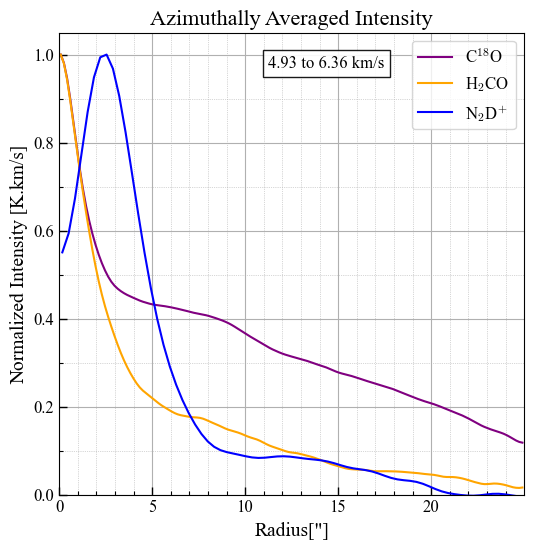

In [18]:
fig, ax = plt.subplots(figsize=(6, 6)) 

v_start_N2Dp = 4.93 * u.km / u.s
v_end_N2Dp   = 6.36 * u.km / u.s

# Make slabs
slab_C18O = cube_C18O.spectral_slab(v_start_N2Dp, v_end_N2Dp)
moment0_C18O = slab_C18O.moment0().value

slab_H2CO = cube_H2CO.spectral_slab(v_start_N2Dp, v_end_N2Dp)
moment0_H2CO = slab_H2CO.moment0().value

slab_N2Dp = cube_N2Dp.spectral_slab(v_start_N2Dp, v_end_N2Dp)
moment0_N2Dp = slab_N2Dp.moment0().value

# Make the radial profile
rp_C18O = RadialProfile(moment0_C18O, xycen, edge_radii)
radius_arcsec_C18O = rp_C18O.radius * pixel_scale
max_C18O = np.nanmax(rp_C18O.profile)
    
# Make the radial profile
rp_H2CO = RadialProfile(moment0_H2CO, xycen, edge_radii)
radius_arcsec_H2CO = rp_H2CO.radius * pixel_scale
max_H2CO = np.nanmax(rp_H2CO.profile)

# Make the radial profile
rp_N2Dp = RadialProfile(moment0_N2Dp, xycen_N2Dp, edge_radii_N2Dp)
radius_arcsec_N2Dp = rp_N2Dp.radius * pixel_scale_N2Dp
max_N2Dp = np.nanmax(rp_N2Dp.profile)

# Plot the radial map
ax.plot(radius_arcsec_C18O, rp_C18O.profile / max_C18O, '-', color='purple', label=r'C$^{18}$O')
ax.plot(radius_arcsec_H2CO, rp_H2CO.profile / max_H2CO, '-', color='orange', label=r'H$_{2}$CO')
ax.plot(radius_arcsec_N2Dp, rp_N2Dp.profile / max_N2Dp, '-', color='blue', label=r'N$_{2}$D$^{+}$')

# Add velocity label in the top left of the subplot
ax.text(0.45, 0.95,
    f"{v_start_N2Dp.value:.2f} to {v_end_N2Dp.value:.2f} km/s",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    color='black',
    bbox=dict(facecolor='white', alpha=0.9))

ax.set_xlim(0, 25) 
ax.set_ylim(0, 1.05)

# Set major ticks every 10 arcseconds
ax.set_xticks(np.arange(0, 25, 5))
ax.set_yticks(np.arange(0, 1.1, 0.2))

# Set minor ticks every 2 arcseconds
ax.set_xticks(np.arange(0, 25, 1), minor=True)
ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

# Customize tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

ax.legend(fontsize=12)

ax.set_title('Azimuthally Averaged Intensity')
ax.set_xlabel('Radius["]')
ax.set_ylabel('Normalized Intensity [K.km/s]')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_azimuthal_profile_same_velocities.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_azimuthal_profile_same_velocities.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# All Channels

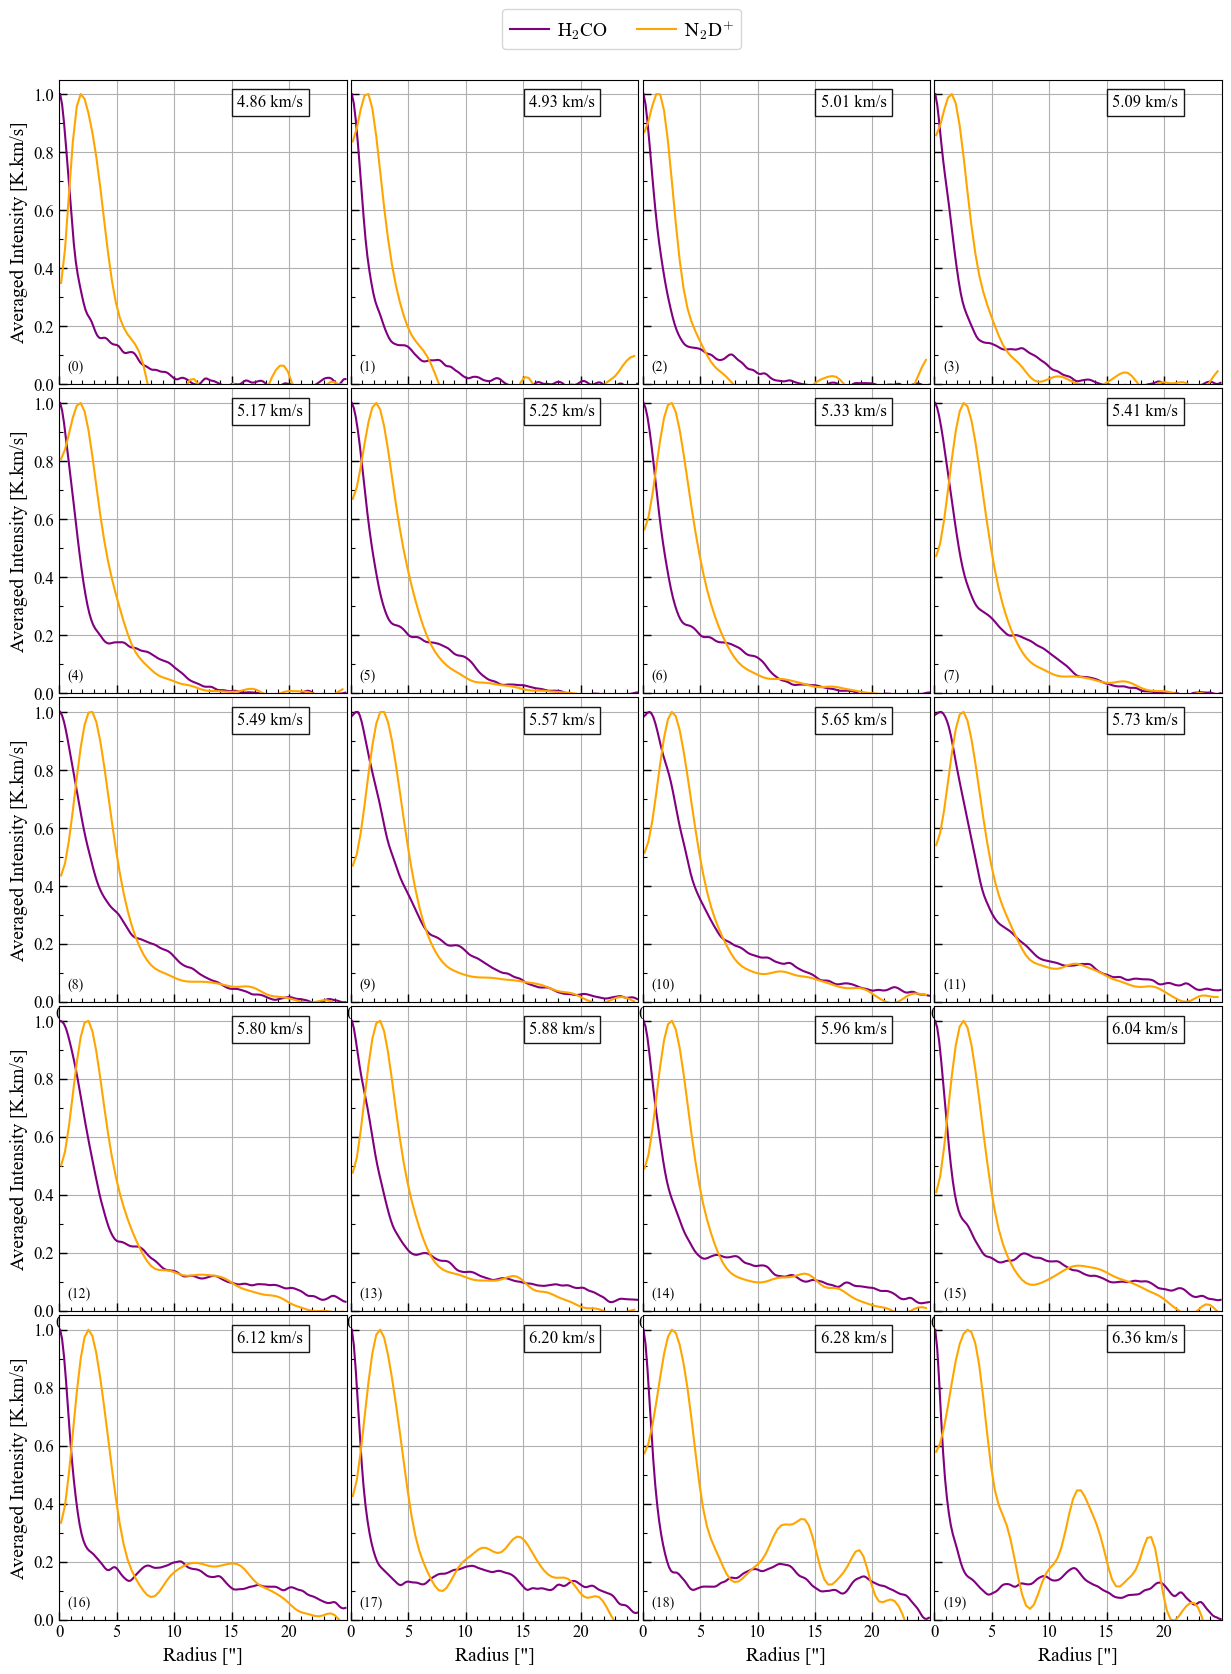

In [19]:
fig, axes = plt.subplots(5, 4, figsize=(15, 20))

for idx, i in enumerate(range(119, 139, 1)):  
    row = idx // 4  # Calculate the row index (0 to 4)
    col = idx % 4   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    # Get velocity for the current slice
    velocity = cube_N2Dp.spectral_axis[i].to(u.km / u.s).value

    # Find channel
    target_velocity = velocity * u.km / u.s
    diff = np.abs(cube_H2CO.spectral_axis - target_velocity)
    channel = np.argmin(diff)

    # Make the radial profile
    rp_H2CO = RadialProfile(cube_H2CO[channel], xycen, edge_radii)
    radius_arcsec_H2CO = rp_H2CO.radius * pixel_scale
    max_H2CO = np.nanmax(rp_H2CO.profile)

    # Make the radial profile
    rp_N2Dp = RadialProfile(cube_N2Dp[i], xycen_N2Dp, edge_radii_N2Dp)
    radius_arcsec_N2Dp = rp_N2Dp.radius * pixel_scale_N2Dp
    max_N2Dp = np.nanmax(rp_N2Dp.profile)

    # Plot the radial map
    ax.plot(radius_arcsec_H2CO, rp_H2CO.profile / max_H2CO, '-', color='purple', label=r'H$_{2}$CO')
    ax.plot(radius_arcsec_N2Dp, rp_N2Dp.profile / max_N2Dp, '-', color='orange', label=r'N$_{2}$D$^{+}$')

    ax.text(0.03, 0.08, f"({idx})",
        transform=ax.transAxes,
        fontsize=10, va='top', ha='left')

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    ax.set_xlim(0, 25) 
    ax.set_ylim(0, 1.05)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(0, 25, 5))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(0, 25, 1), minor=True)
    ax.set_yticks(np.arange(0, 1.1, 0.1), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Radius ["]')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Averaged Intensity [K.km/s]')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), fontsize=14, ncol=2, columnspacing=1.5, handletextpad=0.4)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# fig.text(0.5, 0.005, "Black contours: N2Dp     |     Orange background: H2CO", ha='center', va='bottom', fontsize=16)

# plt.savefig("HOPS164_N2Dp_over_13CO_channel_map_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_over_13CO_channel_map_comparison.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# One moment maps

In [58]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

# Transform it to the same offset frame as your image
marker_offset = marker_coord.transform_to(offset_frame)

# Access robust data
data_robust = cube_C18O.hdu.data

# Convert pixel grid to world coordinates
nx = cube_C18O.shape[1]
ny = cube_C18O.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_C18O.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_C18O.wcs.celestial)

In [22]:
sigma_C18O = 0.13 

# Finding RMS
dv = np.abs(np.diff(slab_C18O.spectral_axis)[0])
N = slab_C18O.shape[0]
sigma_C18O = sigma_C18O * np.sqrt(N) * dv
print(sigma_C18O)

0.04596813023357024 km / s


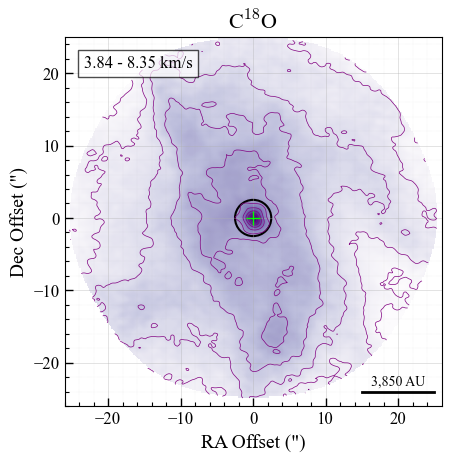

In [23]:
# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(moment0_C18O, origin='lower', cmap='Purples', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(moment0_C18O.data, 'purple', sigma_C18O, sigma_min=5, sigma_max=250, sigma_step=20)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
ax.set_title(r'C$^{18}$O')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{3.84:.2f} - {8.35:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
# plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
# beam_C18O = beam(1.30, 1.03, 85.77, 16, 15)
# ax.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

circle = Circle(
    (0, 0),        # center at protostar
    2.5,           # radius in arcseconds
    edgecolor='black',
    facecolor='none',
    linewidth=1.5,
    linestyle='-'
)

ax.add_patch(circle)

# Save image
plt.savefig("HOPS164_C18O_contour_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_C18O_contour_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

In [24]:
# # Coordinates that APPEAR at the center of the protostar in ALMA data
# marker_coord = SkyCoord("5h37m00.540s", "-6d37m10.75s", frame='icrs')

# # Create a sky offset frame centered on the marker
# offset_frame = marker_coord.skyoffset_frame()

# # Transform it to the same offset frame as your image
# marker_offset = marker_coord.transform_to(offset_frame)

# # Access robust data
# data_robust = cube_H2CO.hdu.data

# # Convert pixel grid to world coordinates
# nx = cube_H2CO.shape[1]
# ny = cube_H2CO.shape[2]
# y_pix, x_pix = np.mgrid[:ny, :nx]
# sky = pixel_to_skycoord(x_pix, y_pix, cube_H2CO.wcs.celestial)

# # Convert sky coordinates to offset frame
# offset_coords = sky.transform_to(offset_frame)
# ra_offsets = offset_coords.lon.arcsec
# dec_offsets = offset_coords.lat.arcsec

# x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_H2CO.wcs.celestial)

In [25]:
sigma_H2CO = 0.11

# Finding RMS
dv = np.abs(np.diff(slab_H2CO.spectral_axis)[0])
N = slab_H2CO.shape[0]
sigma_H2CO = sigma_H2CO * np.sqrt(N) * dv
print(sigma_H2CO)

0.039134626077902565 km / s


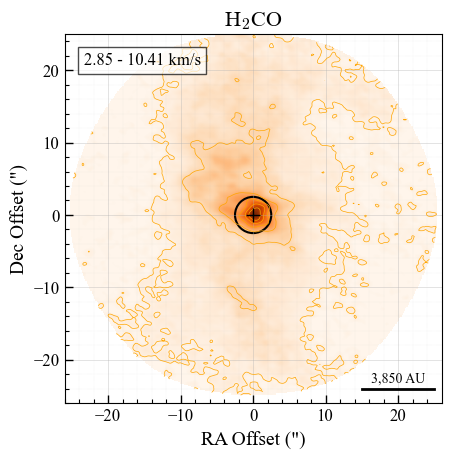

In [26]:
# v_start_C18O = 3.84 * u.km / u.s
# v_end_C18O = 8.35 * u.km / u.s

# v_start_H2CO = 2.85 * u.km / u.s
# v_end_H2CO = 10.41 * u.km / u.s

# v_start_N2Dp = 4.93 * u.km / u.s
# v_end_N2Dp   = 6.36 * u.km / u.s

# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(moment0_H2CO, origin='lower', cmap='Oranges', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()
])

# Plot contours
plot_contours(moment0_H2CO.data, 'orange', sigma_H2CO, sigma_min=5, sigma_max=250, sigma_step=20)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
ax.set_title(r'H$_2$CO')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{2.85:.2f} - {10.41:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
# plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
# beam_C18O = beam(1.30, 1.03, 85.77, 16, 15)
# ax.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

circle = Circle(
    (0, 0),        # center at protostar
    2.5,           # radius in arcseconds
    edgecolor='black',
    facecolor='none',
    linewidth=1.5,
    linestyle='-'
)

ax.add_patch(circle)

# Save image
plt.savefig("HOPS164_H2CO_contour_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_H2CO_contour_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

In [27]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

# Transform it to the same offset frame as your image
marker_offset = marker_coord.transform_to(offset_frame)

# Access robust data
data_robust = cube_N2Dp.hdu.data

# Convert pixel grid to world coordinates
nx = cube_N2Dp.shape[1]
ny = cube_N2Dp.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_N2Dp.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_N2Dp.wcs.celestial)

In [28]:
# sigma_N2Dp = 0.008
sigma_N2Dp = 0.16 # sm_reb

# Finding RMS
dv = np.abs(np.diff(slab_N2Dp.spectral_axis)[0])
N = slab_N2Dp.shape[0]
sigma_N2Dp = sigma_N2Dp * np.sqrt(N) * dv
print(sigma_N2Dp)

0.05517106055222745 km / s


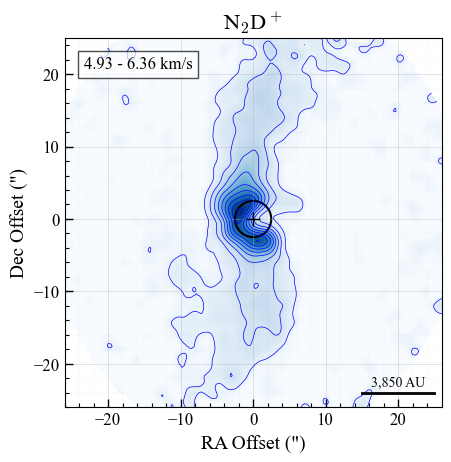

In [29]:
# v_start_C18O = 3.84 * u.km / u.s
# v_end_C18O = 8.35 * u.km / u.s

# v_start_H2CO = 2.85 * u.km / u.s
# v_end_H2CO = 10.41 * u.km / u.s

# v_start_N2Dp = 4.93 * u.km / u.s
# v_end_N2Dp   = 6.36 * u.km / u.s

# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(moment0_N2Dp, origin='lower', cmap='Blues', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(moment0_N2Dp.data, 'blue', sigma_N2Dp, sigma_min=3, sigma_max=40, sigma_step=5)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

circle = Circle(
    (0, 0),        # center at protostar
    2.5,           # radius in arcseconds
    edgecolor='black',
    facecolor='none',
    linewidth=1.5,
    linestyle='-'
)

ax.add_patch(circle)

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
ax.set_title(r'N$_2$D$^+$')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{4.93:.2f} - {6.36:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
# plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
# beam_C18O = beam(1.30, 1.03, 85.77, 16, 15)
# ax.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
plt.savefig("HOPS164_N2Dp_contour_map.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_N2Dp_contour_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

In [30]:
# 2.5" * 385 = 962.5 AU

# Images for Systematic Velocity

In [108]:
cube_H2CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_H2CO = cube_H2CO.to(u.K).with_spectral_unit(u.km/u.s)

cube_C18O=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked.fits')
cube_C18O = cube_C18O.to(u.K).with_spectral_unit(u.km/u.s)

In [109]:
v_start_C18O = 3.84
v_end_C18O = 8.35 

v_start_H2CO = 2.85
v_end_H2CO = 10.41

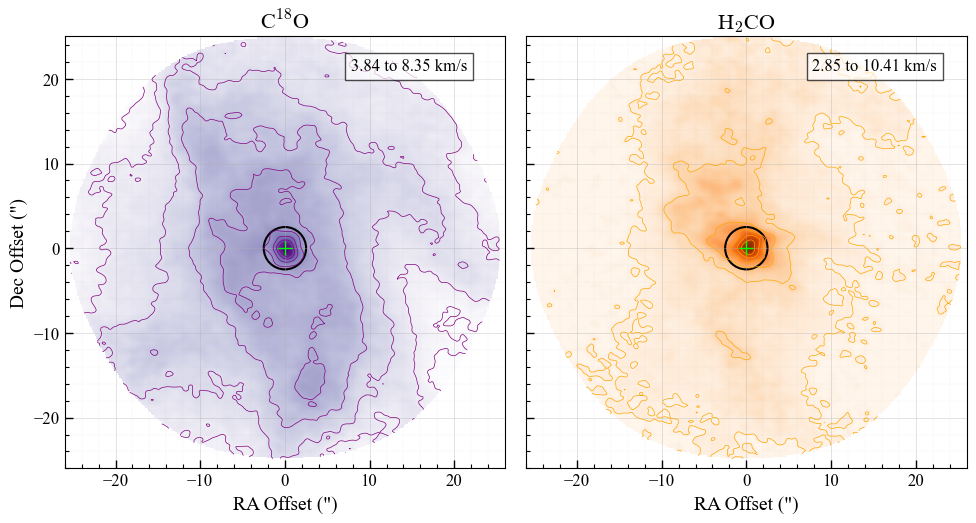

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

#################################################
# RIGHT PANEL — N2Dp
#################################################

ax = axes[0]

im2 = ax.imshow(
    moment0_C18O,
    origin='lower',
    cmap='Purples',
    vmin=0,
    extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()
    ]
)

plot_contours(
    moment0_C18O.data,
    'purple',
    sigma_C18O,
    sigma_min=5,
    sigma_max=250,
    sigma_step=20
)

ax.plot(0, 0, marker='+', color='lime', markersize=10)

# Add velocity label in the top left of the subplot
ax.text(0.65, 0.95, f"{v_start_C18O:.2f} to {v_end_C18O:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

ax.set_ylabel('Dec Offset (")')
ax.set_title(r'C$^{18}$O')


#################################################
# LEFT PANEL — H2CO
#################################################

ax = axes[1]

im1 = ax.imshow(
    moment0_H2CO,
    origin='lower',
    cmap='Oranges',
    vmin=0,
    extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()
    ]
)

plot_contours(
    moment0_H2CO.data,
    'orange',
    sigma_H2CO,
    sigma_min=5,
    sigma_max=250,
    sigma_step=20
)

ax.plot(0, 0, marker='+', color='lime', markersize=10)

# Add velocity label in the top left of the subplot
ax.text(0.65, 0.95, f"{v_start_H2CO:.2f} to {v_end_H2CO:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

ax.set_title(r'H$_2$CO')

#################################################
# SHARED FORMATTING
#################################################

for ax in axes:

    ax.set_xlim(-26, 26)
    ax.set_ylim(-25, 25)

    ax.set_xlabel('RA Offset (")')

    # Set major ticks      
    ax.set_xticks(np.arange(-20, 25, 10))
    ax.set_yticks(np.arange(-20, 25, 10))

    # Set minor ticks  
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-26, 26, 2), minor=True)

    ax.tick_params(axis='both', which='major',
                   length=6, width=1, direction='in')

    ax.tick_params(axis='both', which='minor',
                   length=3, width=0.8, direction='in')

    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

    circle = Circle(
        (0, 0),
        2.5,
        edgecolor='black',
        facecolor='none',
        linewidth=1.5
    )

    ax.add_patch(circle)

#################################################
# SPACING
#################################################

# Hide right-panel y labels
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelleft=False)

# plt.subplots_adjust(wspace=0.1)

plt.tight_layout()

plt.savefig("HOPS164_C18O_H2CO_moment0_comparison.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_C18O_H2CO_moment0_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()

In [111]:
radius = 2.5  # arcsec

r = np.sqrt(ra_offsets**2 + dec_offsets**2)

circle_mask = r <= radius

In [112]:
masked_cube_C18O = cube_C18O.with_mask(circle_mask)
masked_cube_H2CO = cube_H2CO.with_mask(circle_mask)

In [113]:
spectrum_C18O = masked_cube_C18O.mean(axis=(1, 2))
spectrum_H2CO = masked_cube_H2CO.mean(axis=(1, 2))

In [114]:
velocity_C18O = cube_C18O.spectral_axis.to(u.km/u.s)
velocity_H2CO = cube_H2CO.spectral_axis.to(u.km/u.s)

# Find peak velocity for C18O
peak_idx_C18O = np.nanargmax(spectrum_C18O)
peak_velocity_C18O = velocity_C18O[peak_idx_C18O].value
print(f"Peak velocity for C18O: {peak_velocity_C18O:.2f} km/s")

# Find peak velocity for H2CO
peak_idx_H2CO = np.nanargmax(spectrum_H2CO)
peak_velocity_H2CO = velocity_H2CO[peak_idx_H2CO].value
print(f"Peak velocity for H2CO: {peak_velocity_H2CO:.2f} km/s")


Peak velocity for C18O: 5.59 km/s
Peak velocity for H2CO: 5.63 km/s


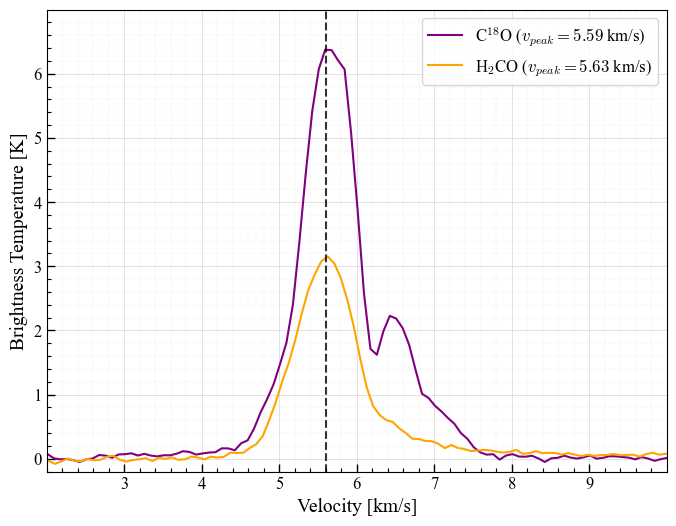

In [115]:
fig, ax = plt.subplots(figsize=(8,6))

# Plot spectra
ax.plot(
    velocity_C18O,
    spectrum_C18O,
    color='purple',
    label=fr'C$^{{18}}$O ($v_{{peak}}={peak_velocity_C18O:.2f}$ km/s)'
)

ax.plot(
    velocity_H2CO,
    spectrum_H2CO,
    color='orange',
    label=fr'H$_2$CO ($v_{{peak}}={peak_velocity_H2CO:.2f}$ km/s)'
)

# Axis limits
ax.set_xlim(2.5, 10)
ax.set_ylim(-0.2, 7)

# Major ticks
ax.set_xticks(np.arange(3, 10, 1))
ax.set_yticks(np.arange(0, 7, 1))

# Minor ticks
ax.set_xticks(np.arange(2, 10, 0.2), minor=True)
ax.set_yticks(np.arange(-0.2, 7, 0.2), minor=True)

# Tick appearance
ax.tick_params(
    axis='both',
    which='major',
    length=6,
    width=1,
    direction='in'
)

ax.tick_params(
    axis='both',
    which='minor',
    length=3,
    width=0.8,
    direction='in'
)

ax.axvline(
    5.6,
    color='black',
    linestyle='--',
    alpha=0.8
)

# Grid
ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.5)

# Labels
ax.set_xlabel('Velocity [km/s]')
ax.set_ylabel('Brightness Temperature [K]')

ax.legend()

# save image
plt.savefig("HOPS164_C18O_H2CO_spectra_comparison.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_C18O_H2CO_spectra_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# v_start_C18O = 3.84 * u.km / u.s
# v_end_C18O = 8.35 * u.km / u.s

# v_start_H2CO = 2.85 * u.km / u.s
# v_end_H2CO = 10.41 * u.km / u.s

# v_start_N2Dp = 4.93 * u.km / u.s
# v_end_N2Dp   = 6.36 * u.km / u.s

# Plot using offsets
fig, ax = plt.subplots()
im = ax.imshow(moment0_N2Dp, origin='lower', cmap='Blues', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

# Plot contours
plot_contours(moment0_N2Dp.data, 'blue', sigma_N2Dp, sigma_min=3, sigma_max=40, sigma_step=5)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='black', markersize=10, label='Marker')

circle = Circle(
    (0, 0),        # center at protostar
    2.5,           # radius in arcseconds
    edgecolor='black',
    facecolor='none',
    linewidth=1.5,
    linestyle='-'
)

ax.add_patch(circle)

# Set labels
ax.set_xlabel('RA Offset (")')
ax.set_ylabel('Dec Offset (")')
# ax.set_title(r'N$_2$D$^+$')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{4.93:.2f} - {6.36:.2f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
# plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
# beam_C18O = beam(1.30, 1.03, 85.77, 16, 15)
# ax.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Change tick appearance
ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 41      
y_start = ax.get_ylim()[0] + 2       

# Length of the bar in arcseconds
scale_bar_length = 10      

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Save image
# plt.savefig("HOPS164_N2Dp_contour_map.png", format="png", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_contour_map.pdf", format="pdf", dpi=300, bbox_inches="tight")

# Close imshow
plt.show()

In [ ]:
v_peaks = {}

for name, file in fits_files.items():

    cube = SpectralCube.read(file)
    cube = cube.with_spectral_unit(u.km/u.s, velocity_convention='radio')

    wcs = cube.wcs

    # --- Get pixel position ---
    x, y = skycoord_to_pixel(source_coord, wcs.celestial)
    x, y = int(x), int(y)

    # --- Pixel scale ---
    pixscale = proj_plane_pixel_scales(wcs.celestial)[0] * 3600  # arcsec/pixel

    radius_arcsec = 1.0
    radius_pix = radius_arcsec / pixscale

    # --- Build circular mask ---
    ny, nx = cube.shape[1], cube.shape[2]
    yy, xx = np.ogrid[:ny, :nx]
    mask = (xx - x)**2 + (yy - y)**2 <= radius_pix**2

    # --- Extract spectrum ---
    spectrum = np.array([
        np.nanmean(channel[mask].value)
        for channel in cube
    ])

    vel_axis = cube.spectral_axis.value

    # centroid (NOT max!)
    v_peak = np.nansum(vel_axis * spectrum) / np.nansum(spectrum)

    v_peaks[name] = v_peak

    print(f"{name}: v_centroid = {v_peak:.2f} km/s")

# --- Systemic velocity ---
good_tracers = ["N2Dp", "C18O"]

velocities = np.array([v_peaks[m] for m in good_tracers])

v_sys = np.mean(velocities)
v_std = np.std(velocities)

print("\n--- Systemic velocity ---")
print(f"v_sys = {v_sys:.2f} ± {v_std:.2f} km/s")